# 02. Feature Engineering
## IBM Telco Customer Churn

**Goal:** Transform raw columns into model-ready features. This notebook does four things:

1. Drops columns with no predictive value
2. Encodes categorical variables with justification for each choice
3. Creates four derived features that capture behavioral signals not in the raw data
4. Scales numeric features and saves the final feature matrix

All logic is also exported to `src/features/build_features.py` so the Streamlit app
and modeling notebook can call a single function instead of duplicating code.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import os, warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

FIG_DIR = "../outputs/figures"
os.makedirs(FIG_DIR, exist_ok=True)

print("Imports complete.")


Imports complete.


---
## 1. Load Raw Data


In [2]:
df = pd.read_excel("../data/Telco_customer_churn.xlsx")
print(f"Raw shape: {df.shape}")
df.head(3)


Raw shape: (7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved


---
## 2. Drop Non-Predictive Columns

The following columns carry no signal for churn prediction:

| Column | Reason for dropping |
|--------|---------------------|
| `CustomerID` | Unique identifier, no signal |
| `Count` | Constant value of 1 for every row |
| `Country`, `State`, `City` | All customers are in the same state/country |
| `Zip Code`, `Lat Long`, `Latitude`, `Longitude` | Geographic granularity not useful here |
| `Churn Score` | Derived target-adjacent variable, would cause data leakage |
| `Churn Reason` | Post-churn label, not available at prediction time |
| `Churn Label` | String version of target. We keep `Churn Value` (0/1) as the target |


In [3]:
DROP_COLS = [
    "CustomerID", "Count", "Country", "State", "City",
    "Zip Code", "Lat Long", "Latitude", "Longitude",
    "Churn Score", "Churn Reason", "Churn Label",
    # CLTV is a business metric derived post-hoc. Keep for now, we'll decide below.
]

df.drop(columns=DROP_COLS, inplace=True)
print(f"Shape after dropping: {df.shape}")
print("Remaining columns:", df.columns.tolist())


Shape after dropping: (7043, 21)
Remaining columns: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value', 'CLTV']


---
## 3. Missing Value Treatment

IBM Telco is a clean dataset, but `Total Charges` can be null for brand-new customers
with zero tenure. We impute with 0, since no charges have yet accrued.


In [4]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.any() else "None found.")

# Impute Total Charges: new customers (Tenure Months == 0) have no charges yet
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")
null_mask = df["Total Charges"].isnull()
print(f"\nNull Total Charges rows: {null_mask.sum()}")
df.loc[null_mask, "Total Charges"] = 0.0
print("Imputed with 0. Nulls remaining:", df["Total Charges"].isnull().sum())


Missing values per column:
None found.

Null Total Charges rows: 11
Imputed with 0. Nulls remaining: 0


---
## 4. Derived Features

Raw columns capture what customers have. Derived features capture *how* they use the service.
We create four features, each with an explicit business rationale.


### 4.1 Tenure Group

**Rationale:** EDA showed churn is non-linear across tenure. A 1-month customer and a
6-month customer are both "short tenure" but behaviorally similar. Bucketing respects the
non-linearity and also produces a feature the business can act on.
We encode ordinally (not one-hot) to preserve the natural order.


In [5]:
bins   = [0, 12, 24, 48, df["Tenure Months"].max() + 1]
labels = ["0-12 mo", "13-24 mo", "25-48 mo", "49+ mo"]
df["Tenure Group"] = pd.cut(df["Tenure Months"], bins=bins, labels=labels, right=True)

# Ordinal encoding: preserves rank order for tree models
tenure_order = {"0-12 mo": 0, "13-24 mo": 1, "25-48 mo": 2, "49+ mo": 3}
df["Tenure Group Enc"] = df["Tenure Group"].map(tenure_order)

print(df["Tenure Group"].value_counts().sort_index())


Tenure Group
0-12 mo     2175
13-24 mo    1024
25-48 mo    1594
49+ mo      2239
Name: count, dtype: int64


### 4.2 Monthly Rate (Total Charges / Tenure)

**Rationale:** `Total Charges` and `Monthly Charges` are correlated but not identical.
`Monthly Rate` normalizes total spend by tenure, producing the actual average spend per month.
For a 1-month customer, Total Charges equals Monthly Charges. For a 36-month customer,
it averages out any plan changes over time. This is a cleaner signal than raw total charges.


In [6]:
# Avoid divide-by-zero for tenure = 0
df["Monthly Rate"] = np.where(
    df["Tenure Months"] > 0,
    df["Total Charges"] / df["Tenure Months"],
    df["Monthly Charges"]   # fallback: use current monthly charges
)

print(df["Monthly Rate"].describe().round(2))


count    7043.00
mean       64.76
std        30.19
min        13.78
25%        35.94
50%        70.34
75%        90.17
max       121.40
Name: Monthly Rate, dtype: float64


### 4.3 Service Count

**Rationale:** Customers who bundle more services are more embedded in the platform.
Switching cost increases with each add-on. A single integer count captures this depth-of-engagement
signal more efficiently than six separate binary columns.


In [7]:
SERVICE_COLS = [
    "Online Security", "Online Backup", "Device Protection",
    "Tech Support", "Streaming TV", "Streaming Movies"
]

# Map "Yes" to 1, everything else to 0
for col in SERVICE_COLS:
    df[col + "_bin"] = (df[col] == "Yes").astype(int)

bin_cols = [c + "_bin" for c in SERVICE_COLS]
df["Service Count"] = df[bin_cols].sum(axis=1)

print("Service Count distribution:")
print(df["Service Count"].value_counts().sort_index())


Service Count distribution:
Service Count
0    2219
1     966
2    1033
3    1118
4     852
5     571
6     284
Name: count, dtype: int64


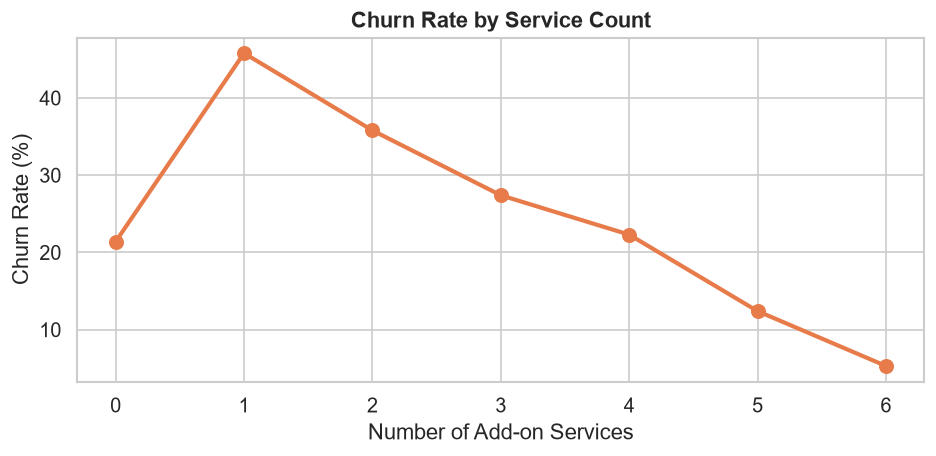

               Churn Rate  Customers  Churn Rate %
Service Count                                     
0                0.214060       2219          21.4
1                0.457557        966          45.8
2                0.358180       1033          35.8
3                0.273703       1118          27.4
4                0.223005        852          22.3
5                0.124343        571          12.4
6                0.052817        284           5.3


In [8]:
# Validate: churn rate drops as service count rises
sc_churn = (df.groupby("Service Count")["Churn Value"]
            .agg(["mean", "count"])
            .rename(columns={"mean": "Churn Rate", "count": "Customers"}))
sc_churn["Churn Rate %"] = (sc_churn["Churn Rate"] * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sc_churn.index, sc_churn["Churn Rate %"], marker="o",
        color="#E87B4A", linewidth=2.5, markersize=8)
ax.set_title("Churn Rate by Service Count", fontweight="bold")
ax.set_xlabel("Number of Add-on Services")
ax.set_ylabel("Churn Rate (%)")
ax.set_xticks(sc_churn.index)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/12_churn_by_service_count.png")
plt.show()
print(sc_churn)


**Validation:** Churn rate falls steadily as service count rises, confirming the
switching-cost hypothesis. This feature will likely rank high in SHAP importance.


### 4.4 High Value Flag

**Rationale:** EDA showed churned customers have higher median monthly charges.
A binary flag for customers above the 75th percentile of monthly charges segments the
customer base by value tier. This allows the model to weight retention decisions
by economic importance, and makes SHAP explanations more interpretable for the business.


In [9]:
p75 = df["Monthly Charges"].quantile(0.75)
df["High Value Flag"] = (df["Monthly Charges"] > p75).astype(int)

print(f"75th percentile monthly charge: ${p75:.2f}")
print(df["High Value Flag"].value_counts())
print(f"\nChurn rate — High Value : {df[df['High Value Flag']==1]['Churn Value'].mean()*100:.1f}%")
print(f"Churn rate — Standard   : {df[df['High Value Flag']==0]['Churn Value'].mean()*100:.1f}%")


75th percentile monthly charge: $89.85
High Value Flag
0    5285
1    1758
Name: count, dtype: int64

Churn rate — High Value : 32.9%
Churn rate — Standard   : 24.4%


### 4.5 Has Household (Partner or Dependents)

**Rationale:** Customers with partners or dependents are switching for a household, not just
themselves. Switching friction is higher. A single compound flag captures this more cleanly
than two separate binary columns.


In [10]:
df["Has Household"] = (
    (df["Partner"] == "Yes") | (df["Dependents"] == "Yes")
).astype(int)

print(df["Has Household"].value_counts())
print(f"\nChurn rate — Has Household : {df[df['Has Household']==1]['Churn Value'].mean()*100:.1f}%")
print(f"Churn rate — No Household  : {df[df['Has Household']==0]['Churn Value'].mean()*100:.1f}%")


Has Household
1    3704
0    3339
Name: count, dtype: int64

Churn rate — Has Household : 19.4%
Churn rate — No Household  : 34.4%


---
## 5. Encoding Categorical Variables

Three encoding strategies, each chosen deliberately:

| Strategy | Applied to | Why |
|----------|-----------|-----|
| **Binary (0/1)** | Yes/No columns | No ordinality, no cardinality problem |
| **Ordinal** | Contract, Tenure Group | Natural rank order exists |
| **One-hot** | Internet Service, Payment Method, Gender | No natural order, low cardinality |


In [11]:
BINARY_COLS = [
    "Partner", "Dependents", "Phone Service",
    "Paperless Billing", "Senior Citizen"
]

for col in BINARY_COLS:
    df[col + "_enc"] = (df[col] == "Yes").astype(int)

# Multiple Lines: "No phone service" treated same as "No"
df["Multiple Lines_enc"] = (df["Multiple Lines"] == "Yes").astype(int)

print("Binary encoding complete.")
print(df[[c + "_enc" for c in BINARY_COLS]].head(3))


Binary encoding complete.
   Partner_enc  Dependents_enc  Phone Service_enc  Paperless Billing_enc  \
0            0               0                  1                      1   
1            0               1                  1                      1   
2            0               1                  1                      1   

   Senior Citizen_enc  
0                   0  
1                   0  
2                   0  


In [12]:
contract_order = {"Month-to-month": 0, "One year": 1, "Two year": 2}
df["Contract_enc"] = df["Contract"].map(contract_order)

print("Contract ordinal encoding:")
print(df["Contract_enc"].value_counts().sort_index())


Contract ordinal encoding:
Contract_enc
0    3875
1    1473
2    1695
Name: count, dtype: int64


In [13]:
OHE_COLS = ["Internet Service", "Payment Method", "Gender"]
df = pd.get_dummies(df, columns=OHE_COLS, drop_first=True, dtype=int)

new_ohe_cols = [c for c in df.columns if any(c.startswith(o) for o in OHE_COLS)]
print("One-hot encoded columns created:")
print(new_ohe_cols)


One-hot encoded columns created:
['Internet Service_Fiber optic', 'Internet Service_No', 'Payment Method_Credit card (automatic)', 'Payment Method_Electronic check', 'Payment Method_Mailed check', 'Gender_Male']


---
## 6. Assemble Final Feature Matrix

Drop the original raw columns that have been encoded or are no longer needed.
Keep `CLTV` as a feature since it captures predicted customer value at the time of modeling.


In [14]:
RAW_TO_DROP = [
    # Originals replaced by encoded versions
    "Partner", "Dependents", "Phone Service", "Multiple Lines",
    "Paperless Billing", "Senior Citizen", "Contract",
    "Tenure Group",
    # Service columns replaced by Service Count
    "Online Security", "Online Backup", "Device Protection",
    "Tech Support", "Streaming TV", "Streaming Movies",
    # Binary versions of service cols (summed into Service Count)
    "Online Security_bin", "Online Backup_bin", "Device Protection_bin",
    "Tech Support_bin", "Streaming TV_bin", "Streaming Movies_bin",
]

df.drop(columns=RAW_TO_DROP, inplace=True)
print(f"Final shape: {df.shape}")
print("Final columns:")
print(df.columns.tolist())


Final shape: (7043, 23)
Final columns:
['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Value', 'CLTV', 'Tenure Group Enc', 'Monthly Rate', 'Service Count', 'High Value Flag', 'Has Household', 'Partner_enc', 'Dependents_enc', 'Phone Service_enc', 'Paperless Billing_enc', 'Senior Citizen_enc', 'Multiple Lines_enc', 'Contract_enc', 'Internet Service_Fiber optic', 'Internet Service_No', 'Payment Method_Credit card (automatic)', 'Payment Method_Electronic check', 'Payment Method_Mailed check', 'Gender_Male']


---
## 7. Scale Numeric Features

Tree-based models (XGBoost) do not need scaling. Logistic regression does.
So, we create a scaled version for the baseline logistic regression, and keep the
unscaled version for XGBoost.

Columns scaled: `Tenure Months`, `Monthly Charges`, `Total Charges`,
`Monthly Rate`, `CLTV`.


In [15]:
TARGET = "Churn Value"

SCALE_COLS = ["Tenure Months", "Monthly Charges", "Total Charges",
              "Monthly Rate", "CLTV"]

# Separate features and target
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Scaled copy for logistic regression
X_scaled = X.copy()
scaler   = StandardScaler()
X_scaled[SCALE_COLS] = scaler.fit_transform(X[SCALE_COLS])

print(f"Feature matrix shape : {X.shape}")
print(f"Target shape         : {y.shape}")
print(f"Churn rate           : {y.mean()*100:.1f}%")


Feature matrix shape : (7043, 22)
Target shape         : (7043,)
Churn rate           : 26.5%


---
## 8. Feature Summary: Distribution Check

A quick visual pass to confirm derived features look reasonable before modeling.


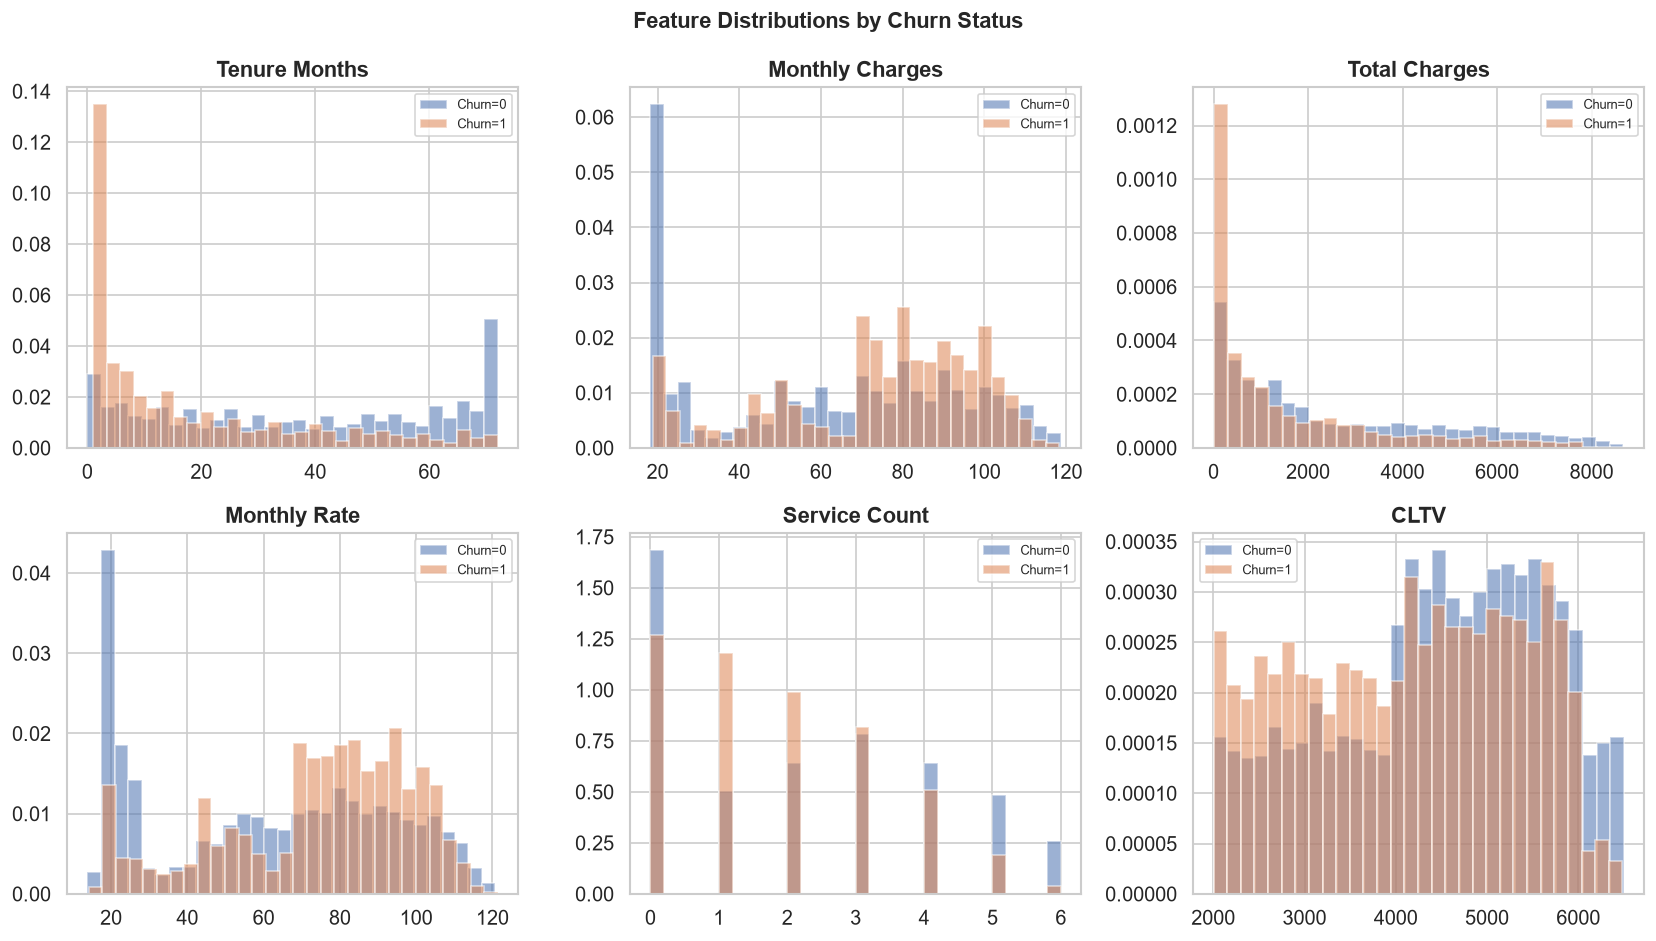

In [16]:
CHECK_COLS = ["Tenure Months", "Monthly Charges", "Total Charges",
              "Monthly Rate", "Service Count", "CLTV"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(CHECK_COLS):
    for label, grp in df.groupby(TARGET):
        axes[i].hist(grp[col], bins=30, alpha=0.55,
                     label=f"Churn={label}", density=True)
    axes[i].set_title(col, fontweight="bold")
    axes[i].legend(fontsize=8)

plt.suptitle("Feature Distributions by Churn Status", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/13_feature_distributions.png")
plt.show()


---
## 9. Save Processed Data


In [ ]:
import os

OUT_DIR = "../outputs"
os.makedirs(OUT_DIR, exist_ok=True)

# Unscaled (for XGBoost and SHAP)
X.to_csv(f"{OUT_DIR}/X_features.csv", index=False)
y.to_csv(f"{OUT_DIR}/y_target.csv",   index=False)

# Scaled (for Logistic Regression baseline)
X_scaled.to_csv(f"{OUT_DIR}/X_scaled.csv", index=False)

print("Saved:")
print(f"  {OUT_DIR}/X_features.csv  — shape {X.shape}")
print(f"  {OUT_DIR}/y_target.csv    — shape {y.shape}")
print(f"  {OUT_DIR}/X_scaled.csv    — shape {X_scaled.shape}")


Saved:
  ../outputs/X_features.csv  — shape (7043, 22)
  ../outputs/y_target.csv    — shape (7043,)
  ../outputs/X_scaled.csv    — shape (7043, 22)


---
## 10. Feature Engineering Summary

| Feature | Type | Source | Business Rationale |
|---------|------|--------|--------------------|
| `Tenure Months` | Numeric | Raw | Core engagement signal |
| `Monthly Charges` | Numeric | Raw | Pricing sensitivity |
| `Total Charges` | Numeric | Raw (imputed) | Lifetime spend |
| `Monthly Rate` | Derived | Total / Tenure | Normalized spend, removes tenure bias |
| `Service Count` | Derived | 6 service cols | Switching cost proxy |
| `High Value Flag` | Derived | Monthly Charges > p75 | Economic importance tier |
| `Has Household` | Derived | Partner OR Dependents | Switching friction |
| `Tenure Group Enc` | Ordinal | Tenure Months | Non-linear tenure effect |
| `Contract_enc` | Ordinal | Contract | Commitment level, 0/1/2 |
| `*_enc` binary cols | Binary | Yes/No cols | Standard 0/1 encoding |
| One-hot cols | One-hot | Internet Service, Payment Method, Gender | Low-cardinality nominals |
| `CLTV` | Numeric | Raw | Predicted customer value |

**Total features going into modeling:** see `X.shape[1]` above.

---
*Next step: `03_modeling.ipynb` — logistic regression baseline, XGBoost,
SMOTE, and full evaluation suite.*
